# Hybrid Field Predictions: Residual Assessment and Reference Correction

A learned field can be compared with the discrete equation that generated its training data. This creates a useful interface between prediction and numerical solution: propose a field, impose the field constraints, measure its residual, and select a reference correction when the required tolerance calls for one.

We reuse the MLP from the previous tutorial and the same course-owned `ToyHelmholtzProblem`. Its equation is $A\mathbf{d}=\mathbf{b}(\lambda)$, with a dimensionless damage-like scalar $d$ on a unit square. The residual therefore measures agreement with this linear field equation.

## The proposal-to-solution sequence

1. **Check the inputs.** Verify the feature order $[x/L,y/H,\lambda]$, tensor shape, finite values, and grid signature.
2. **Predict and project.** Evaluate the fixed MLP under `torch.no_grad()`, restrict values to $[0,1]$, and use the previous field to impose a pointwise lower bound. Set boundary values to zero.
3. **Measure agreement with the equation.** Evaluate the dimensionless relative residual

$$
\rho(\widehat{\mathbf d};\lambda)
=\frac{\|A\widehat{\mathbf d}-\mathbf b(\lambda)\|_2}
       {\|\mathbf b(\lambda)\|_2+10^{-15}}.
$$

4. **Select the result.** Accept the projected proposal when $\rho\le\tau$. Otherwise obtain the reference field using the direct linear solve `torch.linalg.solve`. This correction computes a fresh solution of the discrete field equation.

The scalar $\tau$ is the acceptance tolerance. The notebook uses a visible teaching threshold so that students can compare an accepted model field, a deliberately perturbed field, and the corrected result. The previous field comes from a smaller positive load, for which the linear model's reference field also has smaller values.

## Follow the calculation

The opening calculation loads the saved checkpoint, or trains it when starting this notebook independently. The next cell obtains a proposal, evaluates its residual, and compares it with the reference. It then perturbs a field to illustrate the correction route. Subsequent cells demonstrate feature-order and finite-input checks, compare full spatial fields, and save the decision metadata.


In [1]:
# Environment setup is measured separately from the classroom computation.
from pathlib import Path
import importlib.metadata
import json
import os
import subprocess
import sys
import time

setup_started = time.perf_counter()
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if not (3, 10) <= sys.version_info[:2] < (3, 13):
    raise RuntimeError("This PhAST snapshot supports Python 3.10–3.12. Select a compatible runtime; see Environment Setup.")

def locate_course_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        for candidate in (base, base / "autumn-school", base / "teaching/ukacm_autumn_school_2026"):
            if (candidate / "notebooks/day2_helpers").is_dir() and (candidate / "vendor/PhAST/src").is_dir():
                return candidate.resolve()
    return None

COURSE_ROOT = locate_course_root()
if COURSE_ROOT is None and IN_COLAB:
    COURSE_ROOT = Path.cwd() / "autumn-school"
    if COURSE_ROOT.exists():
        raise RuntimeError("An incomplete autumn-school folder exists. Start a fresh runtime or select the complete course folder.")
    # A release tag or full commit can be supplied for a fixed course edition.
    course_ref = os.environ.get("PHAST_COURSE_REF", "main")
    subprocess.run(["git", "init", str(COURSE_ROOT)], check=True, capture_output=True)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "remote", "add", "origin", "https://github.com/CEMS-Lab/autumn-school.git"], check=True)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "fetch", "--depth", "1", "origin", course_ref], check=True, timeout=180)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "checkout", "--detach", "FETCH_HEAD"], check=True, capture_output=True)
if COURSE_ROOT is None:
    raise FileNotFoundError("Open the notebook from the complete course folder, including notebooks/, configs/ and vendor/. See Environment Setup.")

if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", str(COURSE_ROOT / "vendor/PhAST"), "nbformat", "nbclient", "nbconvert"], check=True, timeout=600)

for package_dir in (COURSE_ROOT / "vendor/PhAST/src", COURSE_ROOT / "notebooks"):
    if str(package_dir) not in sys.path:
        sys.path.insert(0, str(package_dir))

revision = subprocess.run(["git", "-C", str(COURSE_ROOT), "rev-parse", "HEAD"], text=True, capture_output=True)
package_versions = {}
for package in ("torch", "numpy", "scipy", "matplotlib", "nbformat"):
    try:
        package_versions[package] = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        package_versions[package] = "install using Environment Setup"
setup_receipt = {
    "environment": "Google Colab" if IN_COLAB else "local",
    "python": sys.version.split()[0],
    "course_revision": revision.stdout.strip() if revision.returncode == 0 else "downloaded archive",
    "versions": package_versions,
    "setup_seconds": round(time.perf_counter() - setup_started, 3),
}
print(setup_receipt)

import matplotlib.pyplot as plt
import numpy as np
import torch
from io import BytesIO
from IPython.display import Image, display
from day2_helpers import assets_dir

torch.set_default_dtype(torch.float64)
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "font.size": 11, "axes.labelsize": 11, "axes.titlesize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
    "figure.titlesize": 13, "figure.dpi": 150, "axes.grid": True,
    "grid.alpha": 0.3, "grid.linestyle": "--", "lines.linewidth": 1.8,
})

def display_figure(figure, dpi=150, alt="Rendered teaching figure"):
    """Retain figures for reading in the book and in a fresh notebook session."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue(), alt=alt))


{'environment': 'local', 'python': '3.10.18', 'course_revision': '077d43d87c55b4fdea720808fc24f040e957e1ea', 'versions': {'torch': '2.8.0', 'numpy': '2.2.6', 'scipy': '1.14.1', 'matplotlib': '3.10.8', 'nbformat': '5.10.4'}, 'setup_seconds': 0.025}


In [2]:
import json
from day2_helpers.course_tools import (
    FEATURE_ORDER, ToyDamageAdapter, ToyHelmholtzProblem,
    load_toy_model, make_toy_checkpoint,
)

checkpoint_path = assets_dir() / "models" / "tiny_damage_mlp.pt"
if not checkpoint_path.exists():
    # This makes the notebook independently executable. In the normal
    # sequence notebook 04 has already produced this exact artifact.
    make_toy_checkpoint(checkpoint_path, epochs=400, force=True)
model, metadata = load_toy_model(checkpoint_path)
problem = ToyHelmholtzProblem()
adapter = ToyDamageAdapter(model, metadata, problem)
print({"interface_version": metadata["interface_version"], "feature_order": metadata["feature_order"], "mesh_signature": metadata["mesh_signature"]})


{'interface_version': 'ukacm-toy-damage-v1', 'feature_order': ['x_over_L', 'y_over_H', 'load_factor'], 'mesh_signature': [25, 13]}


In [3]:
# Compatible held-out request. d_previous comes from a lower-load state.
load_factor = 0.94
d_previous = problem.reference_field(0.82)
proposal = adapter.propose(problem.features(load_factor), d_previous=d_previous)
assessment = adapter.assess(proposal, load_factor, residual_limit=0.30)
reference = problem.reference_field(load_factor)
corrected = proposal if assessment["accepted"] else adapter.fallback(load_factor, d_previous)
print({"normal_proposal": assessment, "field_rmse": float(torch.sqrt(torch.mean((proposal-reference)**2)))})
assert assessment["accepted"], assessment

# A deliberately corrupted field is projected but fails the same residual gate.
corrupted = torch.where(
    problem.boundary_mask,
    torch.zeros_like(proposal),
    (proposal + 0.30 * torch.sin(12 * problem.coordinates[:, 0])).clamp(0, 1),
)
rejected = adapter.assess(corrupted, load_factor, residual_limit=0.30)
fallback = adapter.fallback(load_factor, d_previous)
print({"corrupted_proposal": rejected, "fallback_residual": problem.relative_residual(fallback, load_factor)})
assert not rejected["accepted"], rejected
assert problem.relative_residual(fallback, load_factor) < 1.0e-10


{'normal_proposal': {'toy_relative_residual': 0.19402747874051113, 'residual_limit': 0.3, 'accepted': True, 'scope': 'Residual of the discrete ToyHelmholtzProblem'}, 'field_rmse': 0.029164814588982523}
{'corrupted_proposal': {'toy_relative_residual': 1.164008876432137, 'residual_limit': 0.3, 'accepted': False, 'scope': 'Residual of the discrete ToyHelmholtzProblem'}, 'fallback_residual': 2.969565304912253e-15}


In [4]:
# Explicitly demonstrate an interface failure instead of silently reshaping input.
try:
    adapter.propose(
        problem.features(load_factor),
        feature_order=("load_factor", "x_over_L", "y_over_H"),
    )
except ValueError as error:
    compatibility_message = str(error)
else:
    raise AssertionError("An incompatible feature order was unexpectedly accepted.")
print("Expected incompatibility:", compatibility_message)

nan_features = problem.features(load_factor).clone()
nan_features[0, 0] = float("nan")
try:
    adapter.propose(nan_features)
except ValueError as error:
    finiteness_message = str(error)
else:
    raise AssertionError("A non-finite adapter input was unexpectedly accepted.")
print("Expected finite-input rejection:", finiteness_message)


Expected incompatibility: Incompatible feature order. Expected ['x_over_L', 'y_over_H', 'load_factor'], got ['load_factor', 'x_over_L', 'y_over_H'].
Expected finite-input rejection: Incompatible feature tensor: all adapter inputs must be finite.


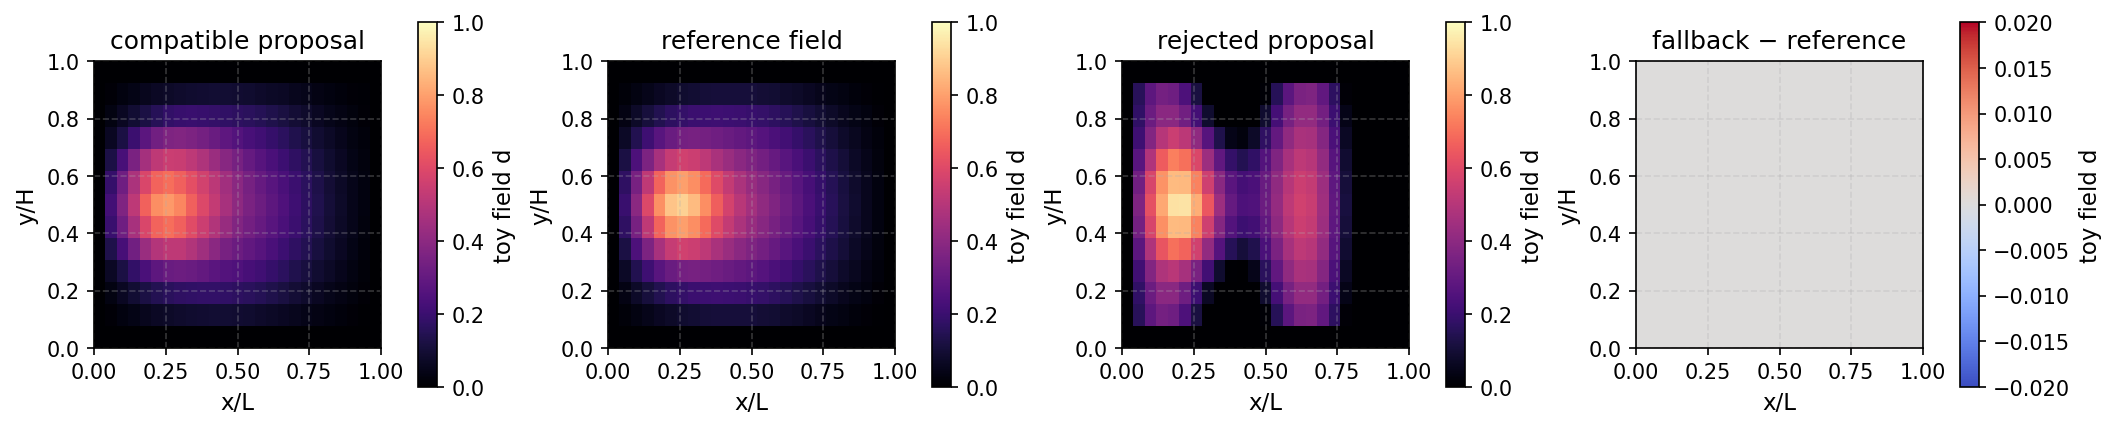

In [5]:
def field_image(values):
    return values.detach().reshape(problem.ny, problem.nx).cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), constrained_layout=True)
panels = (
    (proposal, "compatible proposal", "magma", (0, 1)),
    (reference, "reference field", "magma", (0, 1)),
    (corrupted, "rejected proposal", "magma", (0, 1)),
    (fallback - reference, "fallback − reference", "coolwarm", (-0.02, 0.02)),
)
for ax, field, title, cmap, limits in zip(axes, *zip(*panels)):
    image = ax.imshow(field_image(field), origin="lower", extent=(0,1,0,1), cmap=cmap, vmin=limits[0], vmax=limits[1])
    ax.set(title=title, xlabel="x/L", ylabel="y/H", aspect="equal")
    fig.colorbar(image, ax=ax, shrink=0.78, label="toy field d")
fig.savefig(assets_dir() / "toy_adapter_fallback.png", dpi=160, bbox_inches="tight")
display_figure(fig, alt="Toy adapter's compatible proposal, reference, rejected proposal, and fallback error.")
plt.close(fig)


In [6]:
# Save decision metadata for this proposal/reference assessment.
# Include reference-label cost in a later retraining comparison.
replay_record = {
    "scope": "course-owned ToyHelmholtzProblem; one offline proposal/reference correction record",
    "load_factor": load_factor,
    "feature_order": list(FEATURE_ORDER),
    "normal_assessment": assessment,
    "rejected_assessment": rejected,
    "correction": "classical ToyHelmholtzProblem reference solve",
    "heldout_evaluation_frozen": True,
}
replay_path = assets_dir() / "toy_adapter_replay_record.json"
replay_path.write_text(json.dumps(replay_record, indent=2), encoding="utf-8")
print({"replay_record": str(replay_path.relative_to(COURSE_ROOT)), "decision": "accept compatible / fallback rejected"})


{'replay_record': 'assets/day2_forward/toy_adapter_replay_record.json', 'decision': 'accept compatible / fallback rejected'}


## Interpreting the residual and correction

Compare the field panels and the residual together. The residual measures satisfaction of the discrete equation; the error relative to the known reference measures field accuracy. Their relationship depends on the operator and the chosen error norm. The acceptance tolerance should therefore reflect the accuracy needed for the intended observation.

The plotted fallback error shows the outcome of the direct reference solve for the current monotone loading example. In this example, the model weights remain fixed during inference, and the correction route computes the reference field independently.

## From a decision record to learning from new states

The saved JSON record contains the load, feature order, residual assessments, and correction description. These metadata explain which decision was taken. A labelled training sample additionally needs the coordinates or mesh, the model inputs and previous state, the proposed field, and the reference field.

A data-aggregation extension can collect states visited during a model-driven rollout, obtain reference labels, append those samples to the training data, retrain the model, and evaluate a fixed held-out set. This repeated state collection is the central idea behind DAgger-style training. Record the cost of prediction, residual checks, reference labels, and retraining when assessing the complete workflow.
